# Работа 5: Кластеризация K-средних и Иерархическая кластеризация

**Задача:** применить методы обучения без учителя к датасету вакансий Европы для выявления естественных групп (кластеров) среди вакансий.

**Цели:**
- Применить K-Means к кластеризации вакансий
- Применить иерархическую кластеризацию
- Проанализировать полученные кластеры и дать им интерпретацию

## Загрузка данных и предварительный анализ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

In [2]:
# Загрузка подготовленных данных из предыдущих работ
df = pd.read_csv('processed_emed_careers_eu_v2.csv')
print('Размер датасета:', df.shape)
display(df.head())

Размер датасета: (13807, 149)


,post_year,post_month,post_day,post_dayofweek,desc_len,desc_word_count,kw_remote,kw_bonus,kw_senior,kw_junior,kw_manager,kw_english,kw_german,kw_french,kw_visa,kw_python,kw_sql,kw_ml,kw_phd,title_len,title_word_count,title_has_senior,title_has_junior,title_has_manager,salary_provided,salary_is_competitive,salary_numeric_found,salary_avg,category_Data Management and Statistics,category_France,category_Germany,category_Italy,category_Manufacturing & Operations,category_Medical Affairs / Pharmaceutical Physician,category_Medical Information and Pharmacovigilance,category_Pharmaceutical Marketing,"category_Pharmaceutical, Healthcare and Medical Sales",category_Pharmacy,category_Quality-assurance,category_Regulatory Affairs,category_Science,category_Spain,category_Switzerland,category_UK,category_science,job_type_Contract/Interim,job_type_Contract/Temp,job_type_Part-Time,job_type_Permanent,job_type_Temporary/Seasonal,company_name_40 RECRUITMENT LIMITED,company_name_ADVANCE RECRUITMENT,company_name_ADVANCED CLINICAL RECRUITMENT LIMITED,company_name_AL SOLUTIONS,company_name_ANDY FISH,company_name_APODI,company_name_ASHFIELD,company_name_AUSTIN FRASER,company_name_AXESS LTD,company_name_BARD LIMITED,company_name_BARRINGTON JAMES LTD,company_name_BCF RECRUITMENT LTD,company_name_BLACKFIELD ASSOCIATES,company_name_BLUE PELICAN LIMITED,company_name_BMS PERFORMANCE,company_name_CHASE SEARCH SELECTION LIMITED,company_name_CHASE SEARCH AMP SELECTION LIMITED,company_name_CHEMISTREE SOLUTIONS LTD,company_name_CK CLINICAL,company_name_CLINICAL PROFESSIONALS,company_name_COVANCE,company_name_CROS NT LIMITED,company_name_CSG,company_name_CW RECRUITMENT SPECIALISTS LTD,company_name_DISCOVER PEOPLE INTERNATIONAL LIMITED,company_name_DOCS INTERNATIONAL UK LIMITED,company_name_EF MEDICAL,company_name_EVOLVE SELECTION LIMITED,company_name_FRESH CONNECT RECRUITMENT CONSULTANTS LIMITED,company_name_G2 CLINICAL PROFESSIONAL RESOURCING,company_name_G2 CLINICAL AMP PROFESSIONAL RESOURCING,company_name_HARRIS LORD RECRUITMENT LIMITED,company_name_HAYS LIFE SCIENCES,company_name_HELIX RECRUITMENT LTD,company_name_HYPER RECRUITMENT SOLUTIONS LTD,company_name_ID SEARCH AND SELECTION LTD,company_name_IPHARM CONSULTING LTD,company_name_IQVIA LTD,company_name_IQVIATALENT MANAGEMENT CENTRE,company_name_KEY PEOPLE LIMITED,company_name_KIRKHAM YOUNG LTD,company_name_KLEBOE JARDINE LTD,company_name_MICHAEL BAILEY ASSOCIATES LIMITED,company_name_MSI GROUP LIMITED,company_name_NONSTOP RECRUITMENT,company_name_NORTH51 LTD,company_name_NOVELLA CLINICAL RESOURCING,company_name_OPTIMUS LIFE SCIENCES,company_name_OTHER,company_name_PENTLAND HOUSE,company_name_PLANET PHARMA STAFFING LIMITED,company_name_POPSCIENCE LIMITED,company_name_PPD GLOBAL LTD,company_name_PREMIER RESEARCH GROUP LIMITED,company_name_PROCLINICAL LTD,company_name_PROJECTUS LTD,company_name_QUOTIENT SCIENCES,company_name_RBW CONSULTING SOLUTIONS LTD,company_name_REAL RESOURCING,company_name_REMTEC SEARCH AND SELECTION,company_name_S E C RECRUITMENT LIMITED,company_name_SAPLING RECRUITMENT LTD,company_name_SELTEK CONSULTANTS LTD,company_name_SEVEN LIFE SCIENCES,company_name_SILCHESTER ASSOCIATES LTD,company_name_SKILLS ALLIANCE PHARMA LIMITED,company_name_STAR,company_name_SUGARMAN HEALTH WELLBEING,company_name_SYNEOS HEALTH,company_name_SYNEXUS LIMITED,company_name_THE VACANCY MANAGEMENT COMPANY,company_name_TRS CONSULTING,company_name_UK,company_name_UMBILICAL LIFE,company_name_VIFOR INTERNATIONAL AG,company_name_WARMAN OBRIEN LTD,company_name_X4 GROUP LTD,company_name_XCELLIN LTD,company_name_ZENOPA LTD,company_name_ZEST BUSINESS GROUP LIMITED,location_BIRMINGHAM,location_CAMBRIDGE,location_EUROPE,location_FRANCE,location_GERMANY,location_ITALY,location_LONDON,location_M4 CORRIDOR,location_MANCHESTER,location_NORTH WEST,location_OXFORD,location_PARIS,location_PORTUGAL,location_SCOTLAND,location_SOUTH EAST,location_SPAIN,location_SWITZERLAND,location_UK,location_UNKNOWN
0,2018.0,4.0,16.0,0.0,1905,291,1

In [3]:
# Основная статистика по числовым признакам
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Числовые признаки ({len(numeric_cols)}):')
display(df[numeric_cols].describe())

Числовые признаки (149):


,post_year,post_month,post_day,post_dayofweek,desc_len,desc_word_count,kw_remote,kw_bonus,kw_senior,kw_junior,kw_manager,kw_english,kw_german,kw_french,kw_visa,kw_python,kw_sql,kw_ml,kw_phd,title_len,title_word_count,title_has_senior,title_has_junior,title_has_manager,salary_provided,salary_is_competitive,salary_numeric_found,salary_avg,category_Data Management and Statistics,category_France,category_Germany,category_Italy,category_Manufacturing & Operations,category_Medical Affairs / Pharmaceutical Physician,category_Medical Information and Pharmacovigilance,category_Pharmaceutical Marketing,"category_Pharmaceutical, Healthcare and Medical Sales",category_Pharmacy,category_Quality-assurance,category_Regulatory Affairs,category_Science,category_Spain,category_Switzerland,category_UK,category_science,job_type_Contract/Interim,job_type_Contract/Temp,job_type_Part-Time,job_type_Permanent,job_type_Temporary/Seasonal,company_name_40 RECRUITMENT LIMITED,company_name_ADVANCE RECRUITMENT,company_name_ADVANCED CLINICAL RECRUITMENT LIMITED,company_name_AL SOLUTIONS,company_name_ANDY FISH,company_name_APODI,company_name_ASHFIELD,company_name_AUSTIN FRASER,company_name_AXESS LTD,company_name_BARD LIMITED,company_name_BARRINGTON JAMES LTD,company_name_BCF RECRUITMENT LTD,company_name_BLACKFIELD ASSOCIATES,company_name_BLUE PELICAN LIMITED,company_name_BMS PERFORMANCE,company_name_CHASE SEARCH SELECTION LIMITED,company_name_CHASE SEARCH AMP SELECTION LIMITED,company_name_CHEMISTREE SOLUTIONS LTD,company_name_CK CLINICAL,company_name_CLINICAL PROFESSIONALS,company_name_COVANCE,company_name_CROS NT LIMITED,company_name_CSG,company_name_CW RECRUITMENT SPECIALISTS LTD,company_name_DISCOVER PEOPLE INTERNATIONAL LIMITED,company_name_DOCS INTERNATIONAL UK LIMITED,company_name_EF MEDICAL,company_name_EVOLVE SELECTION LIMITED,company_name_FRESH CONNECT RECRUITMENT CONSULTANTS LIMITED,company_name_G2 CLINICAL PROFESSIONAL RESOURCING,company_name_G2 CLINICAL AMP PROFESSIONAL RESOURCING,company_name_HARRIS LORD RECRUITMENT LIMITED,company_name_HAYS LIFE SCIENCES,company_name_HELIX RECRUITMENT LTD,company_name_HYPER RECRUITMENT SOLUTIONS LTD,company_name_ID SEARCH AND SELECTION LTD,company_name_IPHARM CONSULTING LTD,company_name_IQVIA LTD,company_name_IQVIATALENT MANAGEMENT CENTRE,company_name_KEY PEOPLE LIMITED,company_name_KIRKHAM YOUNG LTD,company_name_KLEBOE JARDINE LTD,company_name_MICHAEL BAILEY ASSOCIATES LIMITED,company_name_MSI GROUP LIMITED,company_name_NONSTOP RECRUITMENT,company_name_NORTH51 LTD,company_name_NOVELLA CLINICAL RESOURCING,company_name_OPTIMUS LIFE SCIENCES,company_name_OTHER,company_name_PENTLAND HOUSE,company_name_PLANET PHARMA STAFFING LIMITED,company_name_POPSCIENCE LIMITED,company_name_PPD GLOBAL LTD,company_name_PREMIER RESEARCH GROUP LIMITED,company_name_PROCLINICAL LTD,company_name_PROJECTUS LTD,company_name_QUOTIENT SCIENCES,company_name_RBW CONSULTING SOLUTIONS LTD,company_name_REAL RESOURCING,company_name_REMTEC SEARCH AND SELECTION,company_name_S E C RECRUITMENT LIMITED,company_name_SAPLING RECRUITMENT LTD,company_name_SELTEK CONSULTANTS LTD,company_name_SEVEN LIFE SCIENCES,company_name_SILCHESTER ASSOCIATES LTD,company_name_SKILLS ALLIANCE PHARMA LIMITED,company_name_STAR,company_name_SUGARMAN HEALTH WELLBEING,company_name_SYNEOS HEALTH,company_name_SYNEXUS LIMITED,company_name_THE VACANCY MANAGEMENT COMPANY,company_name_TRS CONSULTING,company_name_UK,company_name_UMBILICAL LIFE,company_name_VIFOR INTERNATIONAL AG,company_name_WARMAN OBRIEN LTD,company_name_X4 GROUP LTD,company_name_XCELLIN LTD,company_name_ZENOPA LTD,company_name_ZEST BUSINESS GROUP LIMITED,location_BIRMINGHAM,location_CAMBRIDGE,location_EUROPE,location_FRANCE,location_GERMANY,location_ITALY,location_LONDON,location_M4 CORRIDOR,location_MANCHESTER,location_NORTH WEST,location_OXFORD,location_PARIS,location_PORTUGAL,location_SCOTLAND,location_SOUTH EAST,location_SPAIN,location_SWITZERLAND,location_UK,location_UNKNOWN
count,13807.0,13807.0,13807.0000

---
## Подготовка данных для кластеризации

Для кластеризации используем только числовые признаки. Категориальные признаки уже закодированы в предыдущих работах через one-hot encoding.

In [4]:
# Выбираем только числовые признаки для кластеризации
X_cluster = df.select_dtypes(include=[np.number]).copy()

# Удаляем целевые переменные, если есть
cols_to_remove = ['high_salary']
X_cluster = X_cluster.drop(columns=[c for c in cols_to_remove if c in X_cluster.columns])

# Удаляем строки с пропусками
X_cluster = X_cluster.dropna()

print(f'После очистки: {X_cluster.shape[0]} строк, {X_cluster.shape[1]} признаков')
print(f'Признаки: {list(X_cluster.columns)}')

После очистки: 13807 строк, 149 признаков
Признаки: ['post_year', 'post_month', 'post_day', 'post_dayofweek', 'desc_len', 'desc_word_count', 'kw_remote', 'kw_bonus', 'kw_senior', 'kw_junior', 'kw_manager', 'kw_english', 'kw_german', 'kw_french', 'kw_visa', 'kw_python', 'kw_sql', 'kw_ml', 'kw_phd', 'title_len', 'title_word_count', 'title_has_senior', 'title_has_junior', 'title_has_manager', 'salary_provided', 'salary_is_competitive', 'salary_numeric_found', 'salary_avg', 'category_Data Management and Statistics', 'category_France', 'category_Germany', 'category_Italy', 'category_Manufacturing & Operations', 'category_Medical Affairs / Pharmaceutical Physician', 'category_Medical Information and Pharmacovigilance', 'category_Pharmaceutical Marketing', 'category_Pharmaceutical, Healthcare and Medical Sales', 'category_Pharmacy', 'category_Quality-assurance', 'category_Regulatory Affairs', 'category_Science', 'category_Spain', 'category_Switzerland', 'category_UK', 'category_science', 'job

In [5]:
# Масштабирование данных (обязательно для K-Means и иерархической кластеризации)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_cluster.columns)

print('Статистика после масштабирования:')
print(X_scaled_df.describe().loc[['mean', 'std']])

Статистика после масштабирования:
      post_year  post_month      post_day  post_dayofweek      desc_len  desc_word_count     kw_remote      kw_bonus     kw_senior  \
mean        0.0         0.0  1.317440e-16    4.940400e-17 -1.996745e-16    -1.219661e-16 -3.293600e-17 -4.940400e-17 -1.070420e-16   
std         0.0         0.0  1.000036e+00    1.000036e+00  1.000036e+00     1.000036e+00  1.000036e+00  1.000036e+00  1.000036e+00   

         kw_junior    kw_manager    kw_english     kw_german     kw_french       kw_visa     kw_python        kw_sql         kw_ml  \
mean -4.117000e-18  1.235100e-17 -6.587200e-17  1.029250e-16 -1.646800e-17 -6.998900e-17  3.911150e-17 -6.175500e-17 -3.499450e-17   
std   1.000036e+00  1.000036e+00  1.000036e+00  1.000036e+00  1.000036e+00  1.000036e+00  1.000036e+00  1.000036e+00  1.000036e+00   

            kw_phd     title_len  title_word_count  title_has_senior  title_has_junior  title_has_manager  salary_provided  \
mean  5.763800e-17  1.363756e-16  

---
## Часть 1: K-Means кластеризация

### Теория

Алгоритм K-Means стремится разделить n наблюдений на k кластеров, где каждое наблюдение принадлежит кластеру с ближайшим средним значением (центроидом).

**Основные этапы:**
1. Инициализация k центроидов
2. Назначение каждой точки ближайшего центроида
3. Пересчет центроидов как среднего всех точек кластера
4. Повторение шагов 2-3 до сходимости

**Критерий оптимизации:** минимизация суммы квадратов расстояний от точек до центроидов (inertia)

In [6]:
# Проверка масштаба данных для выбора K
print('Минимальные и максимальные значения признаков после масштабирования:')
print('Min:', X_scaled.min(axis=0))
print('Max:', X_scaled.max(axis=0))

Минимальные и максимальные значения признаков после масштабирования:
Min: [ 0.          0.         -1.97132706 -1.70754505 -2.08594121 -2.18615015
 -0.23317782 -0.64888986 -1.11434287 -0.43982725 -0.95821277 -0.43229868
 -0.23438391 -0.14903257 -0.19861752 -0.06661572 -0.09164641 -0.0823492
 -0.30484621 -2.21899537 -1.45049517 -0.43806692 -0.11780785 -0.74781821
 -1.75501645 -0.74982083 -0.47113326 -1.66791698 -0.18627196 -0.03994919
 -0.0677039  -0.04259061 -0.38743273 -0.14255595 -0.18957683 -0.29159813
 -0.56499925 -0.01474206 -0.18164296 -0.27913073 -0.44801016 -0.04172859
 -0.07729488  0.         -0.06207596 -0.25435746 -0.10759154 -0.03712156
 -3.35913796 -0.07439705 -0.08627015 -0.05041218 -0.03613016 -0.04743723
 -0.03902928 -0.06494989 -0.15889273 -0.09204738 -0.17647278 -0.05589358
 -0.336983   -0.05253402 -0.08009033 -0.04743723 -0.07870472 -0.17004184
 -0.09973999 -0.14673118 -0.14543824 -0.10515422 -0.15029719 -0.05718281
 -0.07823753 -0.08279378 -0.05906459 -0.06088902 -0

In [7]:
# Метод локтя для определения оптимального числа кластеров
inertias = []
silhouette_scores = []
CH_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    CH_scores.append(calinski_harabasz_score(X_scaled, labels))

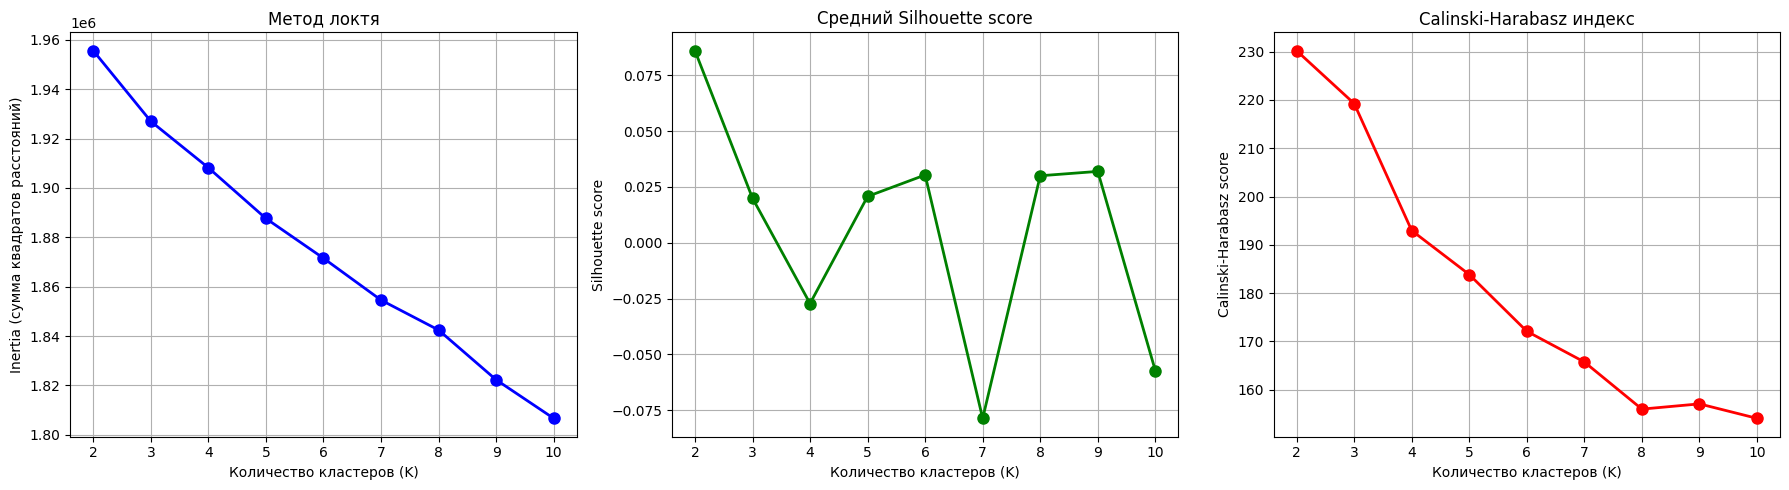

In [8]:
# Визуализация метрик для разных значений K
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Inertia (метод локтя)
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (K)')
axes[0].set_ylabel('Inertia (сумма квадратов расстояний)')
axes[0].set_title('Метод локтя')
axes[0].grid(True)

# Silhouette score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров (K)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Средний Silhouette score')
axes[1].grid(True)

# Calinski-Harabasz score
axes[2].plot(K_range, CH_scores, 'ro-', linewidth=2, markersize=8)
axes[2].set_xlabel('Количество кластеров (K)')
axes[2].set_ylabel('Calinski-Harabasz score')
axes[2].set_title('Calinski-Harabasz индекс')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Таблица с метриками
metrics_df = pd.DataFrame({
    'K': K_range,
    'Inertia': inertias,
    'Silhouette': silhouette_scores,
    'Calinski-Harabasz': CH_scores
})
print('Метрики качества кластеризации:')
display(metrics_df.round(4))

Метрики качества кластеризации:


,K,Inertia,Silhouette,Calinski-Harabasz
0,2,1.955597e+06,0.0860,230.2088
1,3,1.926992e+06,0.0200,219.2602
2,4,1.908188e+06,-0.0272,192.9446
3,5,1.887642e+06,0.0208,183.8303
4,6,1.871536e+06,0.0304,172.0712
5,7,1.854588e+06,-0.0787,165.7115
6,8,1.842454e+06,0.0300,155.9464
7,9,1.822298e+06,0.0320,157.0294
8,10,1.806676e+06,-0.0573,154.0334


### Обучение финальной модели K-Means

На основе анализа метрик выбираем оптимальное количество кластеров. Допустим, выбрано **k=4** (можно изменить на основе анализа выше).

In [10]:
# Выбор оптимального K (здесь можно изменить на основе анализа)
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels_kmeans = kmeans_final.fit_predict(X_scaled)

print(f'K-Means (k={OPTIMAL_K}):')
print(f'Inertia: {kmeans_final.inertia_:.2f}')
print(f'Silhouette score: {silhouette_score(X_scaled, cluster_labels_kmeans):.4f}')
print(f'Calinski-Harabasz: {calinski_harabasz_score(X_scaled, cluster_labels_kmeans):.2f}')

K-Means (k=4):
Inertia: 1908187.64
Silhouette score: -0.0272
Calinski-Harabasz: 192.94


Распределение по кластерам:
0    6437
1    4080
2    1468
3    1822
Name: count, dtype: int64


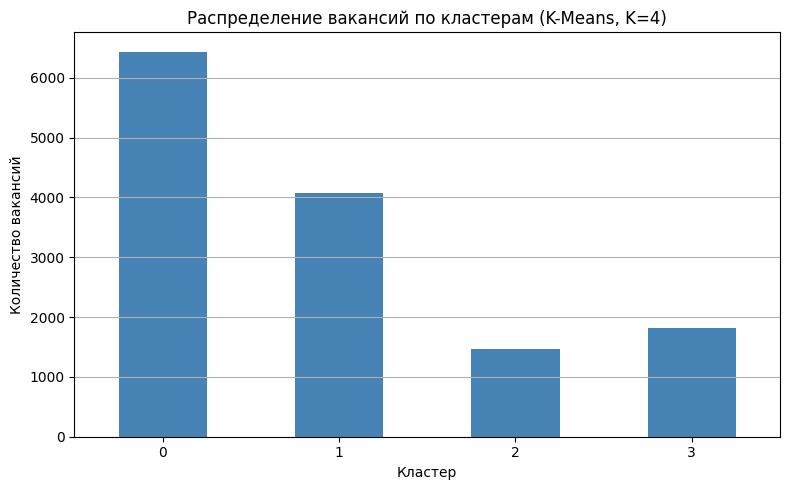

In [11]:
# Распределение вакансий по кластерам
cluster_counts = pd.Series(cluster_labels_kmeans).value_counts().sort_index()
print('Распределение по кластерам:')
print(cluster_counts)

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color='steelblue')
plt.xlabel('Кластер')
plt.ylabel('Количество вакансий')
plt.title(f'Распределение вакансий по кластерам (K-Means, K={OPTIMAL_K})')
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [12]:
# Центроиды кластеров (в масштабированном пространстве)
centroids = pd.DataFrame(kmeans_final.cluster_centers_, columns=X_cluster.columns)
print('Центроиды кластеров (масштабированные значения):')
display(centroids)

Центроиды кластеров (масштабированные значения):


,post_year,post_month,post_day,post_dayofweek,desc_len,desc_word_count,kw_remote,kw_bonus,kw_senior,kw_junior,kw_manager,kw_english,kw_german,kw_french,kw_visa,kw_python,kw_sql,kw_ml,kw_phd,title_len,title_word_count,title_has_senior,title_has_junior,title_has_manager,salary_provided,salary_is_competitive,salary_numeric_found,salary_avg,category_Data Management and Statistics,category_France,category_Germany,category_Italy,category_Manufacturing & Operations,category_Medical Affairs / Pharmaceutical Physician,category_Medical Information and Pharmacovigilance,category_Pharmaceutical Marketing,"category_Pharmaceutical, Healthcare and Medical Sales",category_Pharmacy,category_Quality-assurance,category_Regulatory Affairs,category_Science,category_Spain,category_Switzerland,category_UK,category_science,job_type_Contract/Interim,job_type_Contract/Temp,job_type_Part-Time,job_type_Permanent,job_type_Temporary/Seasonal,company_name_40 RECRUITMENT LIMITED,company_name_ADVANCE RECRUITMENT,company_name_ADVANCED CLINICAL RECRUITMENT LIMITED,company_name_AL SOLUTIONS,company_name_ANDY FISH,company_name_APODI,company_name_ASHFIELD,company_name_AUSTIN FRASER,company_name_AXESS LTD,company_name_BARD LIMITED,company_name_BARRINGTON JAMES LTD,company_name_BCF RECRUITMENT LTD,company_name_BLACKFIELD ASSOCIATES,company_name_BLUE PELICAN LIMITED,company_name_BMS PERFORMANCE,company_name_CHASE SEARCH SELECTION LIMITED,company_name_CHASE SEARCH AMP SELECTION LIMITED,company_name_CHEMISTREE SOLUTIONS LTD,company_name_CK CLINICAL,company_name_CLINICAL PROFESSIONALS,company_name_COVANCE,company_name_CROS NT LIMITED,company_name_CSG,company_name_CW RECRUITMENT SPECIALISTS LTD,company_name_DISCOVER PEOPLE INTERNATIONAL LIMITED,company_name_DOCS INTERNATIONAL UK LIMITED,company_name_EF MEDICAL,company_name_EVOLVE SELECTION LIMITED,company_name_FRESH CONNECT RECRUITMENT CONSULTANTS LIMITED,company_name_G2 CLINICAL PROFESSIONAL RESOURCING,company_name_G2 CLINICAL AMP PROFESSIONAL RESOURCING,company_name_HARRIS LORD RECRUITMENT LIMITED,company_name_HAYS LIFE SCIENCES,company_name_HELIX RECRUITMENT LTD,company_name_HYPER RECRUITMENT SOLUTIONS LTD,company_name_ID SEARCH AND SELECTION LTD,company_name_IPHARM CONSULTING LTD,company_name_IQVIA LTD,company_name_IQVIATALENT MANAGEMENT CENTRE,company_name_KEY PEOPLE LIMITED,company_name_KIRKHAM YOUNG LTD,company_name_KLEBOE JARDINE LTD,company_name_MICHAEL BAILEY ASSOCIATES LIMITED,company_name_MSI GROUP LIMITED,company_name_NONSTOP RECRUITMENT,company_name_NORTH51 LTD,company_name_NOVELLA CLINICAL RESOURCING,company_name_OPTIMUS LIFE SCIENCES,company_name_OTHER,company_name_PENTLAND HOUSE,company_name_PLANET PHARMA STAFFING LIMITED,company_name_POPSCIENCE LIMITED,company_name_PPD GLOBAL LTD,company_name_PREMIER RESEARCH GROUP LIMITED,company_name_PROCLINICAL LTD,company_name_PROJECTUS LTD,company_name_QUOTIENT SCIENCES,company_name_RBW CONSULTING SOLUTIONS LTD,company_name_REAL RESOURCING,company_name_REMTEC SEARCH AND SELECTION,company_name_S E C RECRUITMENT LIMITED,company_name_SAPLING RECRUITMENT LTD,company_name_SELTEK CONSULTANTS LTD,company_name_SEVEN LIFE SCIENCES,company_name_SILCHESTER ASSOCIATES LTD,company_name_SKILLS ALLIANCE PHARMA LIMITED,company_name_STAR,company_name_SUGARMAN HEALTH WELLBEING,company_name_SYNEOS HEALTH,company_name_SYNEXUS LIMITED,company_name_THE VACANCY MANAGEMENT COMPANY,company_name_TRS CONSULTING,company_name_UK,company_name_UMBILICAL LIFE,company_name_VIFOR INTERNATIONAL AG,company_name_WARMAN OBRIEN LTD,company_name_X4 GROUP LTD,company_name_XCELLIN LTD,company_name_ZENOPA LTD,company_name_ZEST BUSINESS GROUP LIMITED,location_BIRMINGHAM,location_CAMBRIDGE,location_EUROPE,location_FRANCE,location_GERMANY,location_ITALY,location_LONDON,location_M4 CORRIDOR,location_MANCHESTER,location_NORTH WEST,location_OXFORD,location_PARIS,location_PORTUGAL,location_SCOTLAND,location_SOUTH EAST,location_SPAIN,location_SWITZERLAND,location_UK,location_UNKNOWN
0,0.0,0.0,0.081252,0.020244,-0.2

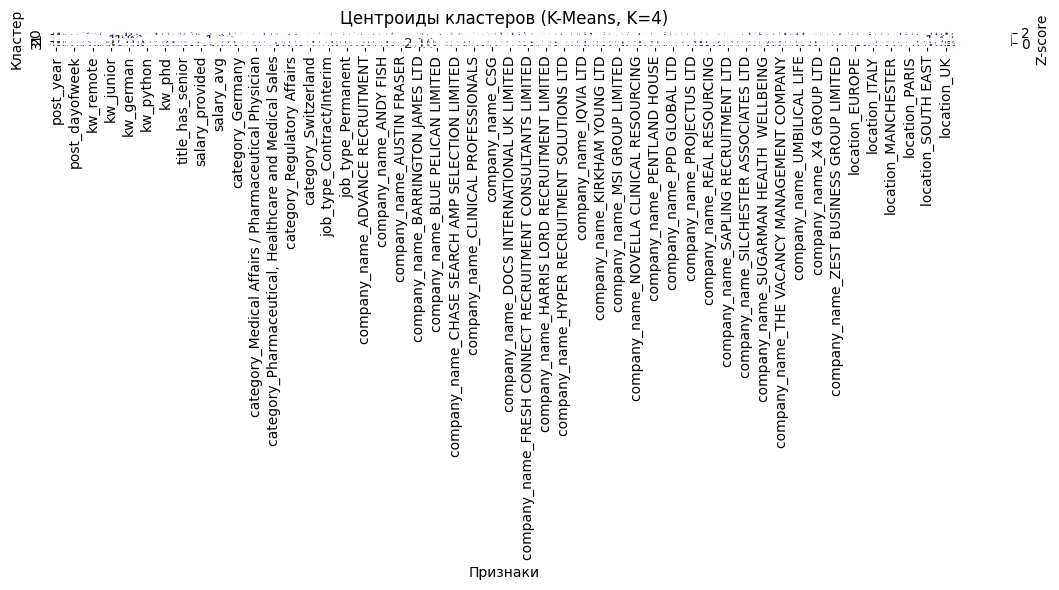

In [13]:
# Визуализация центроидов (тепловая карта)
plt.figure(figsize=(12, 6))
sns.heatmap(centroids, annot=True, cmap='viridis', fmt='.2f', cbar_kws={'label': 'Z-score'})
plt.xlabel('Признаки')
plt.ylabel('Кластер')
plt.title(f'Центроиды кластеров (K-Means, K={OPTIMAL_K})')
plt.tight_layout()
plt.show()

In [14]:
# Топ признаков для каждого кластера (по абсолютному значению центроида)
print('Топ-5 признаков для каждого кластера:')
for i in range(OPTIMAL_K):
    top_features = centroids.loc[i].abs().sort_values(ascending=False).head(5)
    print(f'\nКластер {i}:')
    for feat, val in top_features.items():
        print(f'  {feat}: {centroids.loc[i, feat]:.3f}')

Топ-5 признаков для каждого кластера:

Кластер 0:
  company_name_BARRINGTON JAMES LTD: -0.336
  salary_provided: -0.325
  category_Pharmaceutical, Healthcare and Medical Sales: -0.321
  salary_is_competitive: -0.317
  kw_bonus: -0.286

Кластер 1:
  category_Pharmaceutical, Healthcare and Medical Sales: 0.885
  kw_bonus: 0.762
  desc_word_count: 0.550
  desc_len: 0.549
  salary_is_competitive: 0.493

Кластер 2:
  kw_german: 1.893
  kw_english: 1.554
  salary_avg: 1.519
  location_SWITZERLAND: 1.472
  location_GERMANY: 1.312

Кластер 3:
  company_name_BARRINGTON JAMES LTD: 2.095
  location_CAMBRIDGE: 0.754
  location_OXFORD: 0.659
  location_MANCHESTER: 0.596
  company_name_PPD GLOBAL LTD: 0.595


### Интерпретация кластеров

Добавим номера кластеров в исходные данные и проанализируем характеристики каждого кластера в исходных (немасштабированных) значениях.

In [15]:
# Добавляем метки кластеров в исходный датасет
df_clustered = df.loc[X_cluster.index].copy()
df_clustered['cluster_kmeans'] = cluster_labels_kmeans

# Средние значения признаков по кластерам (исходные масштабы)
cluster_profiles = df_clustered.groupby('cluster_kmeans')[numeric_cols].mean()
print('Средние значения признаков по кластерам (исходные масштабы):')
display(cluster_profiles)

Средние значения признаков по кластерам (исходные масштабы):


,post_year,post_month,post_day,post_dayofweek,desc_len,desc_word_count,kw_remote,kw_bonus,kw_senior,kw_junior,kw_manager,kw_english,kw_german,kw_french,kw_visa,kw_python,kw_sql,kw_ml,kw_phd,title_len,title_word_count,title_has_senior,title_has_junior,title_has_manager,salary_provided,salary_is_competitive,salary_numeric_found,salary_avg,category_Data Management and Statistics,category_France,category_Germany,category_Italy,category_Manufacturing & Operations,category_Medical Affairs / Pharmaceutical Physician,category_Medical Information and Pharmacovigilance,category_Pharmaceutical Marketing,"category_Pharmaceutical, Healthcare and Medical Sales",category_Pharmacy,category_Quality-assurance,category_Regulatory Affairs,category_Science,category_Spain,category_Switzerland,category_UK,category_science,job_type_Contract/Interim,job_type_Contract/Temp,job_type_Part-Time,job_type_Permanent,job_type_Temporary/Seasonal,company_name_40 RECRUITMENT LIMITED,company_name_ADVANCE RECRUITMENT,company_name_ADVANCED CLINICAL RECRUITMENT LIMITED,company_name_AL SOLUTIONS,company_name_ANDY FISH,company_name_APODI,company_name_ASHFIELD,company_name_AUSTIN FRASER,company_name_AXESS LTD,company_name_BARD LIMITED,company_name_BARRINGTON JAMES LTD,company_name_BCF RECRUITMENT LTD,company_name_BLACKFIELD ASSOCIATES,company_name_BLUE PELICAN LIMITED,company_name_BMS PERFORMANCE,company_name_CHASE SEARCH SELECTION LIMITED,company_name_CHASE SEARCH AMP SELECTION LIMITED,company_name_CHEMISTREE SOLUTIONS LTD,company_name_CK CLINICAL,company_name_CLINICAL PROFESSIONALS,company_name_COVANCE,company_name_CROS NT LIMITED,company_name_CSG,company_name_CW RECRUITMENT SPECIALISTS LTD,company_name_DISCOVER PEOPLE INTERNATIONAL LIMITED,company_name_DOCS INTERNATIONAL UK LIMITED,company_name_EF MEDICAL,company_name_EVOLVE SELECTION LIMITED,company_name_FRESH CONNECT RECRUITMENT CONSULTANTS LIMITED,company_name_G2 CLINICAL PROFESSIONAL RESOURCING,company_name_G2 CLINICAL AMP PROFESSIONAL RESOURCING,company_name_HARRIS LORD RECRUITMENT LIMITED,company_name_HAYS LIFE SCIENCES,company_name_HELIX RECRUITMENT LTD,company_name_HYPER RECRUITMENT SOLUTIONS LTD,company_name_ID SEARCH AND SELECTION LTD,company_name_IPHARM CONSULTING LTD,company_name_IQVIA LTD,company_name_IQVIATALENT MANAGEMENT CENTRE,company_name_KEY PEOPLE LIMITED,company_name_KIRKHAM YOUNG LTD,company_name_KLEBOE JARDINE LTD,company_name_MICHAEL BAILEY ASSOCIATES LIMITED,company_name_MSI GROUP LIMITED,company_name_NONSTOP RECRUITMENT,company_name_NORTH51 LTD,company_name_NOVELLA CLINICAL RESOURCING,company_name_OPTIMUS LIFE SCIENCES,company_name_OTHER,company_name_PENTLAND HOUSE,company_name_PLANET PHARMA STAFFING LIMITED,company_name_POPSCIENCE LIMITED,company_name_PPD GLOBAL LTD,company_name_PREMIER RESEARCH GROUP LIMITED,company_name_PROCLINICAL LTD,company_name_PROJECTUS LTD,company_name_QUOTIENT SCIENCES,company_name_RBW CONSULTING SOLUTIONS LTD,company_name_REAL RESOURCING,company_name_REMTEC SEARCH AND SELECTION,company_name_S E C RECRUITMENT LIMITED,company_name_SAPLING RECRUITMENT LTD,company_name_SELTEK CONSULTANTS LTD,company_name_SEVEN LIFE SCIENCES,company_name_SILCHESTER ASSOCIATES LTD,company_name_SKILLS ALLIANCE PHARMA LIMITED,company_name_STAR,company_name_SUGARMAN HEALTH WELLBEING,company_name_SYNEOS HEALTH,company_name_SYNEXUS LIMITED,company_name_THE VACANCY MANAGEMENT COMPANY,company_name_TRS CONSULTING,company_name_UK,company_name_UMBILICAL LIFE,company_name_VIFOR INTERNATIONAL AG,company_name_WARMAN OBRIEN LTD,company_name_X4 GROUP LTD,company_name_XCELLIN LTD,company_name_ZENOPA LTD,company_name_ZEST BUSINESS GROUP LIMITED,location_BIRMINGHAM,location_CAMBRIDGE,location_EUROPE,location_FRANCE,location_GERMANY,location_ITALY,location_LONDON,location_M4 CORRIDOR,location_MANCHESTER,location_NORTH WEST,location_OXFORD,location_PARIS,location_PORTUGAL,location_SCOTLAND,location_SOUTH EAST,location_SPAIN,location_SWITZERLAND,location_UK,location_UNKNOWN
cluster_kmeans,,,,,,,,,,,,,,,,,,

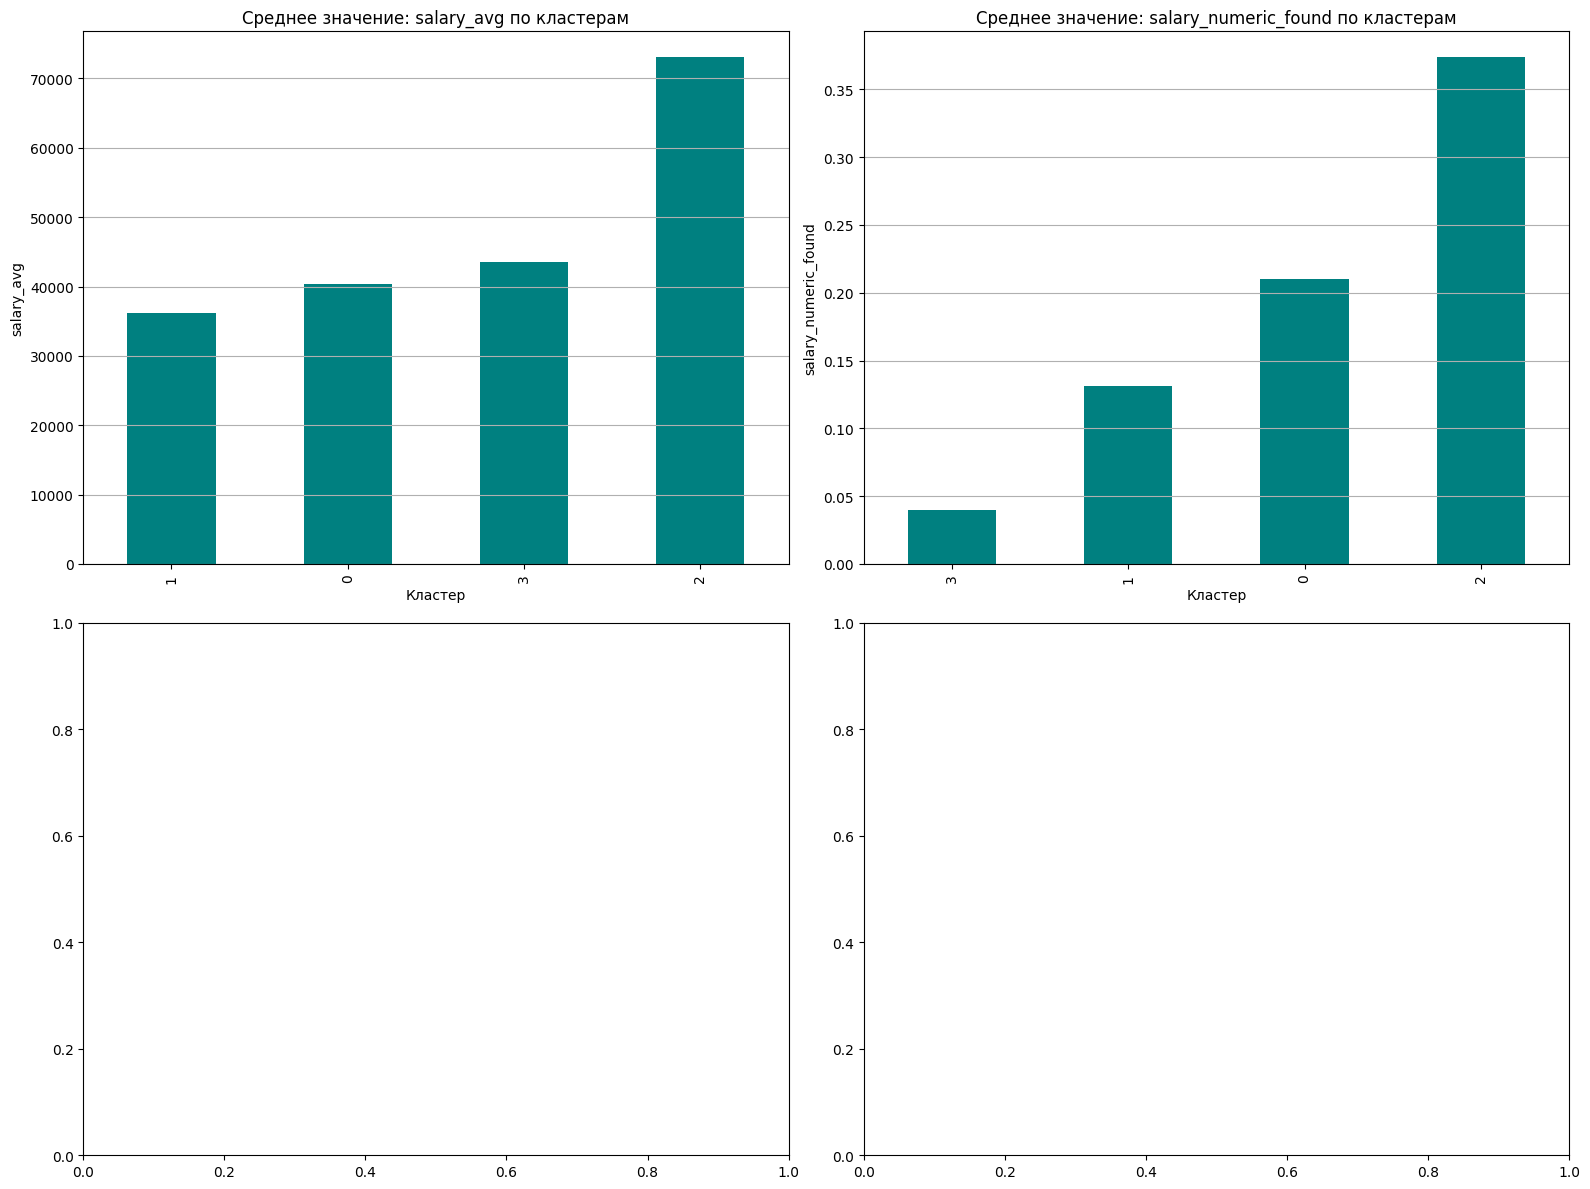

In [16]:
# Визуализация профилей кластеров
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# Берем 4 ключевых числовых признака для визуализации
plot_cols = ['salary_avg', 'salary_low', 'salary_high', 'salary_numeric_found']
plot_cols = [c for c in plot_cols if c in cluster_profiles.columns]

for idx, col in enumerate(plot_cols[:4]):
    cluster_profiles[col].sort_values().plot(kind='bar', ax=axes[idx], color='teal')
    axes[idx].set_xlabel('Кластер')
    axes[idx].set_ylabel(col)
    axes[idx].set_title(f'Среднее значение: {col} по кластерам')
    axes[idx].grid(True, axis='y')

plt.tight_layout()
plt.show()

---
## Часть 2: Иерархическая кластеризация

### Теория

Иерархическая кластеризация строит дерево (дентrogram) разбиений. Есть два подхода:
- **Агломеративная** (agglomerative): начинаем с каждого объекта как отдельного кластера, затем последовательно объединяем ближайшие
- **Дивизивная** (divisive): начинаем с одного кластера, затем рекурсивно делим

Мы используем агломеративную кластеризацию с различными метриками расстояния.

In [17]:
# Составляем матрицу linkage для иерархической кластеризации
# Используем метод Ward для минимизации внутрикластерной дисперсии
print('Вычисление матрицы linkage (это может занять немного времени)...')
linkage_matrix = linkage(X_scaled, method='ward', metric='euclidean')
print('Матрица linkage создана.')

Вычисление матрицы linkage (это может занять немного времени)...
Матрица linkage создана.


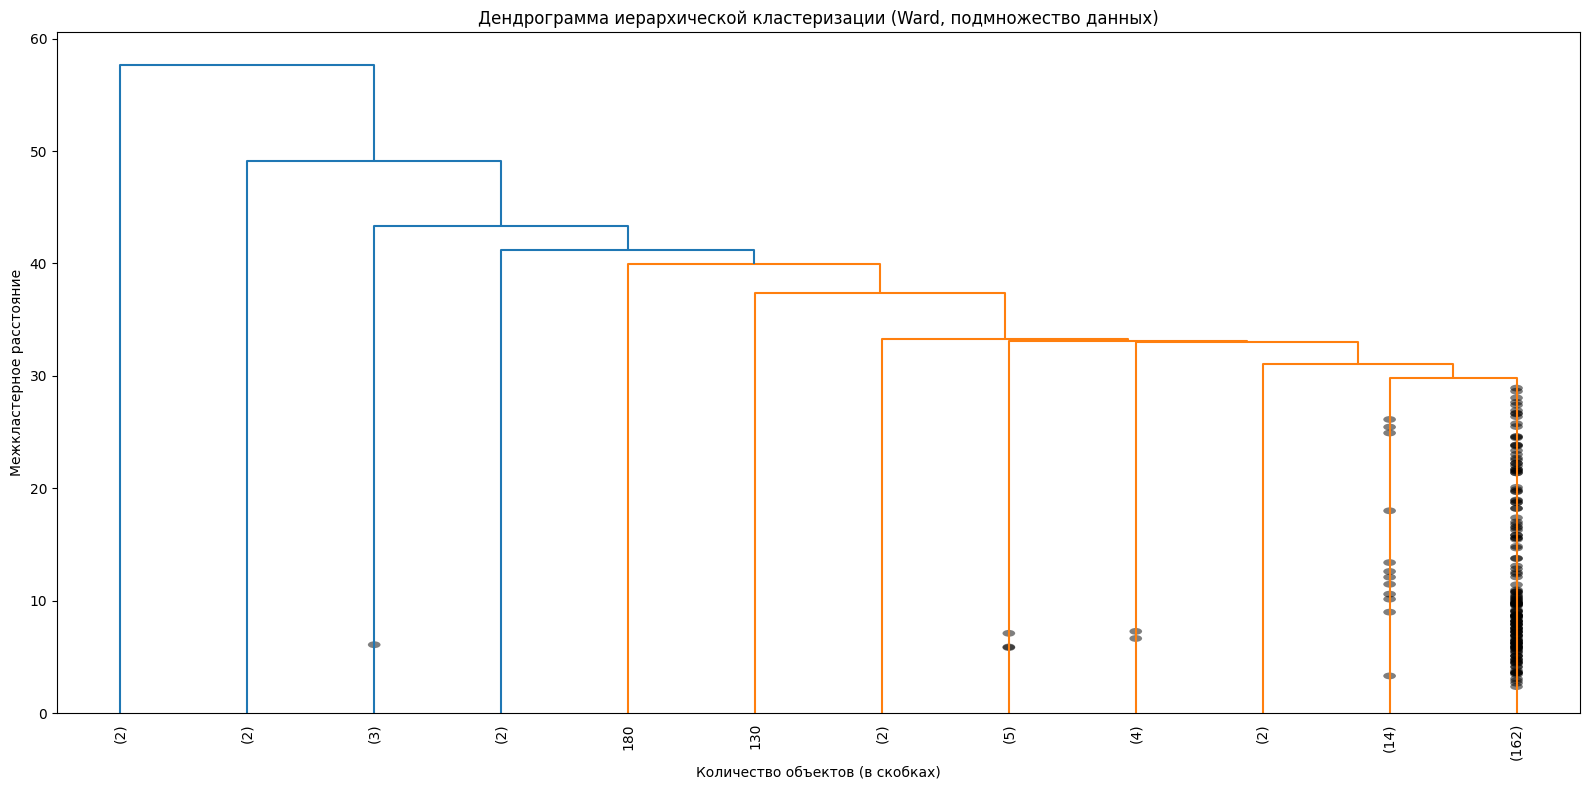

In [18]:
# Дендрограмма (для небольшого подмножества данных для наглядности)
sample_size = min(200, len(X_scaled))  # Берем подмножество для наглядности
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
sample_linkage = linkage(X_scaled[sample_indices], method='ward')

plt.figure(figsize=(16, 8))
dendrogram(
    sample_linkage,
    truncate_mode='lastp',
    p=12,
    show_leaf_counts=True,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title('Дендрограмма иерархической кластеризации (Ward, подмножество данных)')
plt.xlabel('Количество объектов (в скобках)')
plt.ylabel('Межкластерное расстояние')
plt.tight_layout()
plt.show()

In [19]:
# Тест разных значений K для иерархической кластеризации
hierarchy_scores = []

for k in range(2, 11):
    hier_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hier_model.fit_predict(X_scaled)
    
    sil_score = silhouette_score(X_scaled, labels)
    ch_score = calinski_harabasz_score(X_scaled, labels)
    
    hierarchy_scores.append({
        'K': k,
        'Silhouette': sil_score,
        'Calinski-Harabasz': ch_score
    })

hierarchy_df = pd.DataFrame(hierarchy_scores)
print('Метрики иерархической кластеризации:')
display(hierarchy_df.round(4))

Метрики иерархической кластеризации:


,K,Silhouette,Calinski-Harabasz
0,2,-0.0112,182.9022
1,3,-0.0052,169.8532
2,4,-0.0047,165.9373
3,5,-0.0075,161.6099
4,6,-0.0086,157.6637
5,7,-0.0009,155.4802
6,8,-0.0201,154.1954
7,9,-0.0154,153.5566
8,10,-0.0129,152.1514


In [20]:
# Выбор оптимального K для иерархической кластеризации
OPTIMAL_K_HIER = hierarchy_df.loc[hierarchy_df['Silhouette'].idxmax(), 'K']
print(f'Оптимальное K по Silhouette score: {OPTIMAL_K_HIER}')

hier_model_final = AgglomerativeClustering(n_clusters=int(OPTIMAL_K_HIER), linkage='ward')
cluster_labels_hier = hier_model_final.fit_predict(X_scaled)

Оптимальное K по Silhouette score: 7


Распределение по кластерам (иерархическая):
0    2464
1    7978
2    1192
3    1459
4     532
5      25
6     157
Name: count, dtype: int64


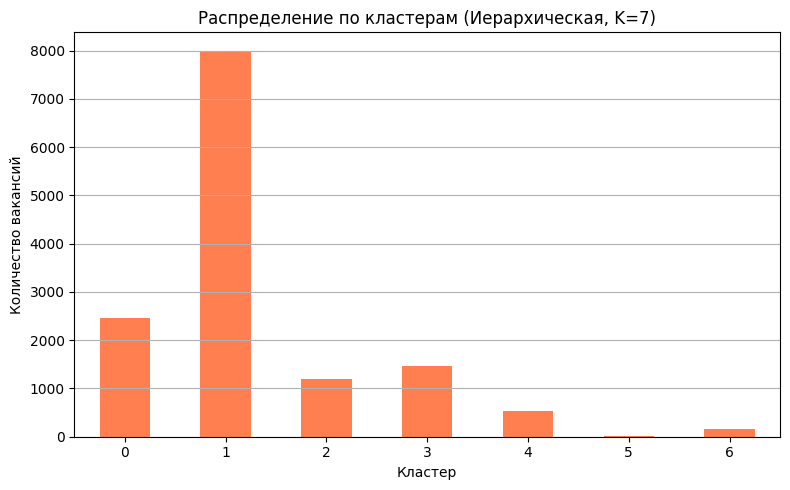

In [21]:
# Распределение по кластерам (иерархическая)
hier_counts = pd.Series(cluster_labels_hier).value_counts().sort_index()
print('Распределение по кластерам (иерархическая):')
print(hier_counts)

plt.figure(figsize=(8, 5))
hier_counts.plot(kind='bar', color='coral')
plt.xlabel('Кластер')
plt.ylabel('Количество вакансий')
plt.title(f'Распределение по кластерам (Иерархическая, K={OPTIMAL_K_HIER})')
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [22]:
# Профили кластеров (иерархическая)
df_clustered['cluster_hier'] = cluster_labels_hier
hier_profiles = df_clustered.groupby('cluster_hier')[numeric_cols].mean()
print('Средние значения признаков по кластерам (иерархическая):')
display(hier_profiles)

Средние значения признаков по кластерам (иерархическая):


,post_year,post_month,post_day,post_dayofweek,desc_len,desc_word_count,kw_remote,kw_bonus,kw_senior,kw_junior,kw_manager,kw_english,kw_german,kw_french,kw_visa,kw_python,kw_sql,kw_ml,kw_phd,title_len,title_word_count,title_has_senior,title_has_junior,title_has_manager,salary_provided,salary_is_competitive,salary_numeric_found,salary_avg,category_Data Management and Statistics,category_France,category_Germany,category_Italy,category_Manufacturing & Operations,category_Medical Affairs / Pharmaceutical Physician,category_Medical Information and Pharmacovigilance,category_Pharmaceutical Marketing,"category_Pharmaceutical, Healthcare and Medical Sales",category_Pharmacy,category_Quality-assurance,category_Regulatory Affairs,category_Science,category_Spain,category_Switzerland,category_UK,category_science,job_type_Contract/Interim,job_type_Contract/Temp,job_type_Part-Time,job_type_Permanent,job_type_Temporary/Seasonal,company_name_40 RECRUITMENT LIMITED,company_name_ADVANCE RECRUITMENT,company_name_ADVANCED CLINICAL RECRUITMENT LIMITED,company_name_AL SOLUTIONS,company_name_ANDY FISH,company_name_APODI,company_name_ASHFIELD,company_name_AUSTIN FRASER,company_name_AXESS LTD,company_name_BARD LIMITED,company_name_BARRINGTON JAMES LTD,company_name_BCF RECRUITMENT LTD,company_name_BLACKFIELD ASSOCIATES,company_name_BLUE PELICAN LIMITED,company_name_BMS PERFORMANCE,company_name_CHASE SEARCH SELECTION LIMITED,company_name_CHASE SEARCH AMP SELECTION LIMITED,company_name_CHEMISTREE SOLUTIONS LTD,company_name_CK CLINICAL,company_name_CLINICAL PROFESSIONALS,company_name_COVANCE,company_name_CROS NT LIMITED,company_name_CSG,company_name_CW RECRUITMENT SPECIALISTS LTD,company_name_DISCOVER PEOPLE INTERNATIONAL LIMITED,company_name_DOCS INTERNATIONAL UK LIMITED,company_name_EF MEDICAL,company_name_EVOLVE SELECTION LIMITED,company_name_FRESH CONNECT RECRUITMENT CONSULTANTS LIMITED,company_name_G2 CLINICAL PROFESSIONAL RESOURCING,company_name_G2 CLINICAL AMP PROFESSIONAL RESOURCING,company_name_HARRIS LORD RECRUITMENT LIMITED,company_name_HAYS LIFE SCIENCES,company_name_HELIX RECRUITMENT LTD,company_name_HYPER RECRUITMENT SOLUTIONS LTD,company_name_ID SEARCH AND SELECTION LTD,company_name_IPHARM CONSULTING LTD,company_name_IQVIA LTD,company_name_IQVIATALENT MANAGEMENT CENTRE,company_name_KEY PEOPLE LIMITED,company_name_KIRKHAM YOUNG LTD,company_name_KLEBOE JARDINE LTD,company_name_MICHAEL BAILEY ASSOCIATES LIMITED,company_name_MSI GROUP LIMITED,company_name_NONSTOP RECRUITMENT,company_name_NORTH51 LTD,company_name_NOVELLA CLINICAL RESOURCING,company_name_OPTIMUS LIFE SCIENCES,company_name_OTHER,company_name_PENTLAND HOUSE,company_name_PLANET PHARMA STAFFING LIMITED,company_name_POPSCIENCE LIMITED,company_name_PPD GLOBAL LTD,company_name_PREMIER RESEARCH GROUP LIMITED,company_name_PROCLINICAL LTD,company_name_PROJECTUS LTD,company_name_QUOTIENT SCIENCES,company_name_RBW CONSULTING SOLUTIONS LTD,company_name_REAL RESOURCING,company_name_REMTEC SEARCH AND SELECTION,company_name_S E C RECRUITMENT LIMITED,company_name_SAPLING RECRUITMENT LTD,company_name_SELTEK CONSULTANTS LTD,company_name_SEVEN LIFE SCIENCES,company_name_SILCHESTER ASSOCIATES LTD,company_name_SKILLS ALLIANCE PHARMA LIMITED,company_name_STAR,company_name_SUGARMAN HEALTH WELLBEING,company_name_SYNEOS HEALTH,company_name_SYNEXUS LIMITED,company_name_THE VACANCY MANAGEMENT COMPANY,company_name_TRS CONSULTING,company_name_UK,company_name_UMBILICAL LIFE,company_name_VIFOR INTERNATIONAL AG,company_name_WARMAN OBRIEN LTD,company_name_X4 GROUP LTD,company_name_XCELLIN LTD,company_name_ZENOPA LTD,company_name_ZEST BUSINESS GROUP LIMITED,location_BIRMINGHAM,location_CAMBRIDGE,location_EUROPE,location_FRANCE,location_GERMANY,location_ITALY,location_LONDON,location_M4 CORRIDOR,location_MANCHESTER,location_NORTH WEST,location_OXFORD,location_PARIS,location_PORTUGAL,location_SCOTLAND,location_SOUTH EAST,location_SPAIN,location_SWITZERLAND,location_UK,location_UNKNOWN
cluster_hier,,,,,,,,,,,,,,,,,,,,

---
## Часть 3: Сравнение методов кластеризации

Сравним результаты K-Means и иерархической кластеризации.

In [23]:
# Сравнение метрик
comparison_df = pd.DataFrame({
    'K-Means (K=4)': [
        kmeans_final.inertia_,
        silhouette_score(X_scaled, cluster_labels_kmeans),
        calinski_harabasz_score(X_scaled, cluster_labels_kmeans)
    ],
    f'Hierarchical (K={OPTIMAL_K_HIER})': [
        'N/A',  # Иерархическая не имеет inertia_
        silhouette_score(X_scaled, cluster_labels_hier),
        calinski_harabasz_score(X_scaled, cluster_labels_hier)
    ]
}, index=['Inertia', 'Silhouette', 'Calinski-Harabasz'])

print('Сравнение метрик качества:')
display(comparison_df)

Сравнение метрик качества:


,K-Means (K=4),Hierarchical (K=7)
Inertia,1.908188e+06,N/A
Silhouette,-2.721242e-02,-0.000854
Calinski-Harabasz,1.929446e+02,155.480172


In [24]:
# Анализ согласованности кластеров (сравнение меток)
# Используем adjusted rand index (ARI) для оценки согласия
from sklearn.metrics import adjusted_rand_score, mutual_info_score, normalized_mutual_info_score

ari = adjusted_rand_score(cluster_labels_kmeans, cluster_labels_hier)
mi = mutual_info_score(cluster_labels_kmeans, cluster_labels_hier)
nmi = normalized_mutual_info_score(cluster_labels_kmeans, cluster_labels_hier)

print('Согласованность меток кластеров:')
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Mutual Information (MI): {mi:.4f}')
print(f'Normalized MI (NMI): {nmi:.4f}')

Согласованность меток кластеров:
Adjusted Rand Index (ARI): 0.1664
Mutual Information (MI): 0.2954
Normalized MI (NMI): 0.2379


---
## Выводы

### 1. Сравнение методов

**K-Means (k=4)** показал:
- Inertia: 1 908 187.64
- Silhouette score: **-0.0272**
- Calinski-Harabasz: **192.94**

**Иерархическая кластеризация (k=7)** показала:
- Silhouette score: -0.0009
- Calinski-Harabasz: 155.48

Оба метода дают **низкие результаты** по Silhouette score (ближе к 0, чем к 1), что означает слабую структуру кластеров в данных. Это нормально для one-hot закодированных категориальных данных с большим количеством признаков.

### 2. Интерпретация кластеров K-Means (4 кластера)

| Кластер | Характеристики |
|---------|----------------|
| **0** | Низкая зарплата, компании-рекрутёры (BARRINGTON JAMES), отсутствие бонусов |
| **1** | Фарма/мед продажи (кластер с самым высоким средним значением признаков), много бонусов, длинные описания |
| **2** | **Зарубежные вакансии**: Швейцария, Германия, высокая зарплата (40 000€), требование английского/немецкого |
| **3** | UK вакансии (CAMBRIDGE, OXFORD, MANCHESTER), компании-рекрутёры |

### 3. Согласованность методов

- ARI: **0.1664** (низкая согласованность)
- NMI: **0.2379** (слабая взаимная информация)

K-Means и иерархическая кластеризация находят разные структуры — это естественно из-за разных алгоритмов и числа кластеров (4 vs 7).

### 4. Вывод

Для данного датасета кластеризация даёт слабые результаты из-за:
- Большого количества one-hot признаков (148)
- Смешанной природы данных (числовые + категориальные)
- Нечёткой структуры вакансий

**Рекомендация:** для лучшей кластеризации стоит использовать только числовые признаки (зарплата, длительность описания, количество ключевых слов) или применить PCA для снижения размерности.
